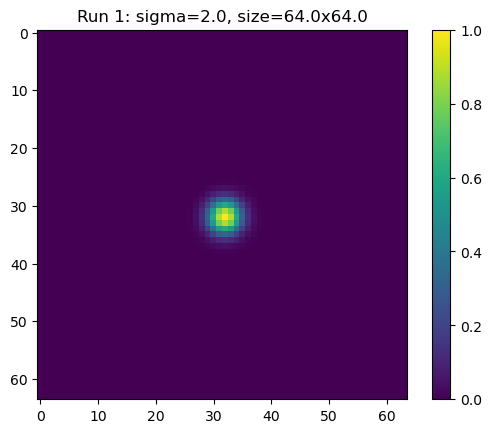

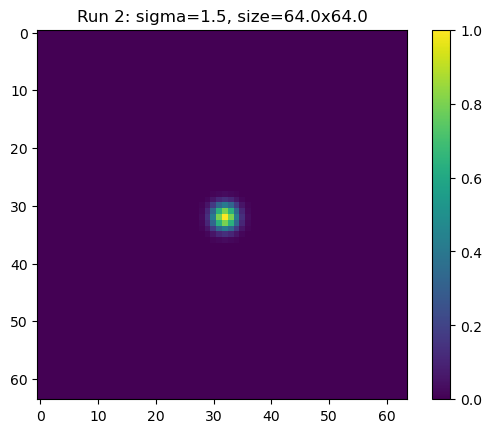

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def make_gaussian_heatmap(size, sigma, center=None):
    """
    size: int -> heatmap size (e.g. 64)
    sigma: float -> Gaussian sigma in heatmap pixels
    center: (x, y) in heatmap coords; default = center of map
    """
    if center is None:
        center = (size / 2, size / 2)

    x = np.arange(0, size, 1)
    y = np.arange(0, size, 1)
    xx, yy = np.meshgrid(x, y)

    heatmap = np.exp(-((xx - center[0])**2 + (yy - center[1])**2) / (2 * sigma**2))
    return heatmap





sigma_1 = 2.0
crop_1 = 128
stride = 2
size_1 = crop_1 / stride  


sigma_2 = 1.5
crop_2 = 128
size_2 = crop_2 / stride  


heatmap_1 = make_gaussian_heatmap(size_1, sigma_1)
heatmap_2 = make_gaussian_heatmap(size_2, sigma_2)



plt.figure()
plt.imshow(heatmap_1)
plt.title(f"Run 1: sigma={sigma_1}, size={size_1}x{size_1}")
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(heatmap_2)
plt.title(f"Run 2: sigma={sigma_2}, size={size_2}x{size_2}")
plt.colorbar()
plt.show()


Resolution: 1040 x 716
Total frames: 27014
Randomly selected frame: 4402


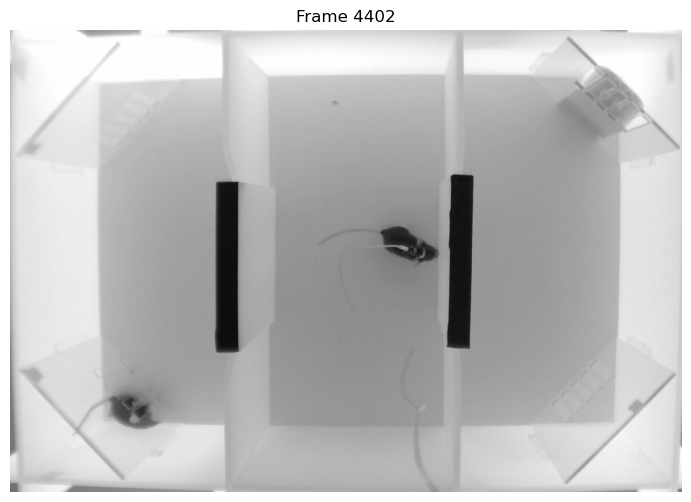

In [3]:



import numpy as np
import random
import matplotlib.pyplot as plt
import cv2
seed = 1
random.seed(seed)


video_path = r'C:\Users\jrall\Desktop\Bachelorarbeit\Bachelor_Joschua\behavior_videos_maxim\1126 - Gen.Vergleich\trial_2\video0030 25-01-23 19-11-32.mp4'


cap = cv2.VideoCapture(video_path) 
if not cap.isOpened():
    print("Error: Cannot open video.")
else:
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Resolution: {width} x {height}")
    print(f"Total frames: {frame_count}")

    random_frame_idx = random.randint(0, frame_count - 1)
    print(f"Randomly selected frame: {random_frame_idx}")

    cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame_idx)
    ret, frame = cap.read() 
    if ret:
        sampled_frame = frame
        
        
        sampled_frame_gray = cv2.cvtColor(sampled_frame, cv2.COLOR_BGR2GRAY)

   
        plt.figure(figsize=(10, 6))
        plt.imshow(sampled_frame_gray, cmap='gray')
        plt.title(f"Frame {random_frame_idx}")
        plt.axis('off')
        plt.show()

    else:
        print("Error: Could not read frame.")
    
    cap.release()

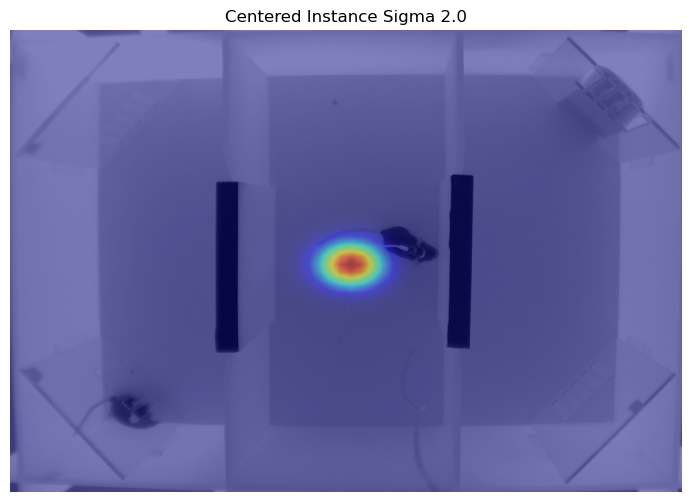

In [4]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt


def make_gaussian_heatmap(size, sigma, center=None):
    if center is None:
        center = (size / 2, size / 2)

    x = np.arange(0, size, 1)
    y = np.arange(0, size, 1)
    xx, yy = np.meshgrid(x, y)

    heatmap = np.exp(-((xx - center[0])**2 + (yy - center[1])**2) / (2 * sigma**2))
    return heatmap



sigma = 2.0
crop_size = 128
output_stride = 2
heatmap_size = crop_size / output_stride   



seed = 1
random.seed(seed)

video_path = r'C:\Users\jrall\Desktop\Bachelorarbeit\Bachelor_Joschua\behavior_videos_maxim\1126 - Gen.Vergleich\trial_2\video0030 25-01-23 19-11-32.mp4'

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video.")
else:
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    random_frame_idx = random.randint(0, frame_count - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame_idx)
    ret, frame = cap.read()

    if ret:
        sampled_frame = frame
        sampled_frame_gray = cv2.cvtColor(sampled_frame, cv2.COLOR_BGR2GRAY)

        
        heatmap = make_gaussian_heatmap(heatmap_size, sigma)

        
        heatmap_resized = cv2.resize(
            heatmap,
            (sampled_frame_gray.shape[1], sampled_frame_gray.shape[0]),
            interpolation=cv2.INTER_LINEAR
        )

        heatmap_norm = heatmap_resized / heatmap_resized.max()

       
        plt.figure(figsize=(10, 6))
        plt.imshow(sampled_frame_gray, cmap='gray')
        plt.imshow(heatmap_norm, cmap='jet', alpha=0.5) 
        plt.title("Centered Instance Sigma 2.0")
        plt.axis('off')
        plt.show()

    else:
        print("Error: Could not read frame.")

    cap.release()


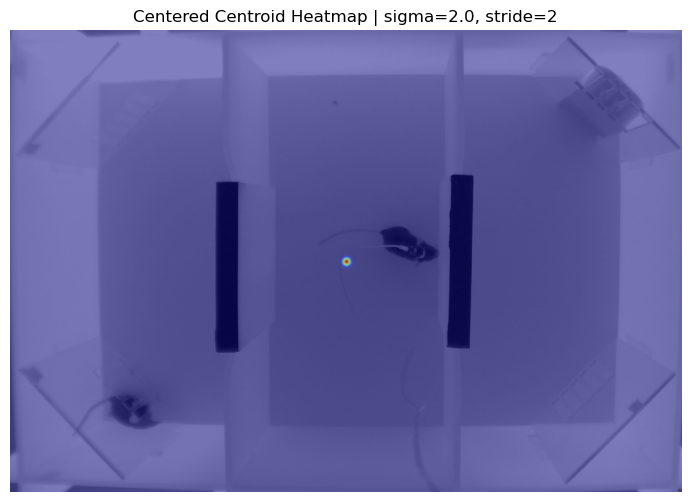

In [5]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt


def make_gaussian_heatmap(height, width, sigma, center=None):
    """
    Erzeugt eine 2D-Gaussian-Heatmap für ein ganzes Bild
    in Heatmap-Auflösung.

    height: Höhe der Heatmap
    width: Breite der Heatmap
    sigma: Breite der Gaussian in Heatmap-Pixeln
    center: (x, y)-Zentrum in Heatmap-Koordinaten
    """
    if center is None:
        center = (width // 2, height // 2)

    x = np.arange(0, width, 1)
    y = np.arange(0, height, 1)
    xx, yy = np.meshgrid(x, y)

    heatmap = np.exp(
        -((xx - center[0]) ** 2 + (yy - center[1]) ** 2) / (2 * sigma ** 2)
    )
    return heatmap


sigma = 2.0
output_stride = 2

seed = 1
random.seed(seed)

video_path = r"C:\Users\jrall\Desktop\Bachelorarbeit\Bachelor_Joschua\behavior_videos_maxim\1126 - Gen.Vergleich\trial_2\video0030 25-01-23 19-11-32.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video.")
else:
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    random_frame_idx = random.randint(0, frame_count - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame_idx)
    ret, frame = cap.read()

    if ret:
        sampled_frame = frame
        sampled_frame_gray = cv2.cvtColor(sampled_frame, cv2.COLOR_BGR2GRAY)

        frame_height, frame_width = sampled_frame_gray.shape

        
        heatmap_height = frame_height // output_stride
        heatmap_width = frame_width // output_stride

        
        heatmap = make_gaussian_heatmap(
            height=heatmap_height,
            width=heatmap_width,
            sigma=sigma,
            center=None
        )

        
        heatmap_resized = cv2.resize(
            heatmap,
            (frame_width, frame_height),
            interpolation=cv2.INTER_LINEAR
        )

        
        heatmap_norm = heatmap_resized / heatmap_resized.max()

        
        plt.figure(figsize=(10, 6))
        plt.imshow(sampled_frame_gray, cmap="gray")
        plt.imshow(heatmap_norm, cmap="jet", alpha=0.5)
        plt.title(f"Centered Centroid Heatmap | sigma={sigma}, stride={output_stride}")
        plt.axis("off")
        plt.show()

    else:
        print("Error: Could not read frame.")

    cap.release()

In [6]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt


def make_gaussian_heatmap(size, sigma, center=None):
    if center is None:
        center = (size // 2, size // 2)

    x = np.arange(0, size, 1)
    y = np.arange(0, size, 1)
    xx, yy = np.meshgrid(x, y)

    heatmap = np.exp(-((xx - center[0])**2 + (yy - center[1])**2) / (2 * sigma**2))
    return heatmap



sigma = 1.5
crop_size = 128
output_stride = 2
heatmap_size = crop_size // output_stride   



seed = 1
random.seed(seed)

video_path = r'C:\Users\jrall\Desktop\Bachelorarbeit\Bachelor_Joschua\behavior_videos_maxim\1126\trial_2\video0030 25-01-23 19-11-32.mp4'

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video.")
else:
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    random_frame_idx = random.randint(0, frame_count - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame_idx)
    ret, frame = cap.read()

    if ret:
        sampled_frame = frame
        sampled_frame_gray = cv2.cvtColor(sampled_frame, cv2.COLOR_BGR2GRAY)

       
        heatmap = make_gaussian_heatmap(heatmap_size, sigma)

        
        heatmap_resized = cv2.resize(
            heatmap,
            (sampled_frame_gray.shape[1], sampled_frame_gray.shape[0]),
            interpolation=cv2.INTER_LINEAR
        )

       
        heatmap_norm = heatmap_resized / heatmap_resized.max()

    
        plt.figure(figsize=(10, 6))
        plt.imshow(sampled_frame_gray, cmap='gray')
        plt.imshow(heatmap_norm, cmap='jet', alpha=0.5)  
        plt.title("Centered Instance Sigma 1.5")
        plt.axis('off')
        plt.show()

    else:
        print("Error: Could not read frame.")

    cap.release()


Error: Cannot open video.


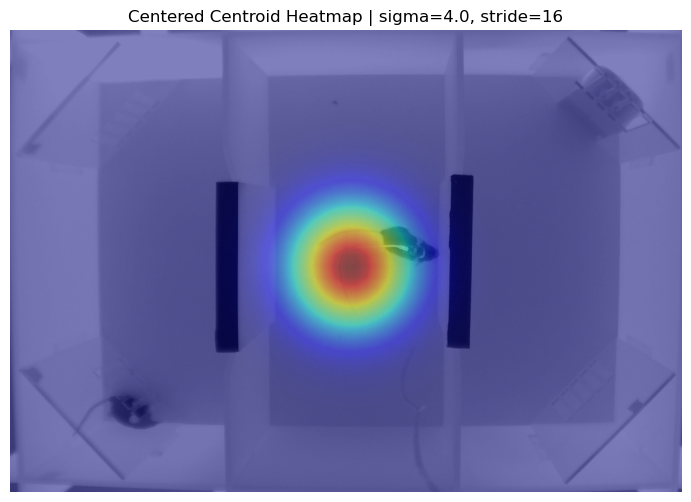

In [7]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt


def make_gaussian_heatmap(height, width, sigma, center=None):
    """
    Erzeugt eine 2D-Gaussian-Heatmap in Heatmap-Auflösung.

    height, width: Größe der Heatmap
    sigma: Sigma in Heatmap-Pixeln
    center: (x, y) in Heatmap-Koordinaten; Standard = Mitte
    """
    if center is None:
        center = (width / 2, height / 2)

    x = np.arange(0, width, 1, dtype=np.float32)
    y = np.arange(0, height, 1, dtype=np.float32)
    xx, yy = np.meshgrid(x, y)

    heatmap = np.exp(
        -((xx - center[0]) ** 2 + (yy - center[1]) ** 2) / (2 * sigma ** 2)
    )
    return heatmap



sigma = 4.0          
output_stride = 16   
seed = 1

random.seed(seed)

video_path = r"C:\Users\jrall\Desktop\Bachelorarbeit\Bachelor_Joschua\behavior_videos_maxim\1126 - Gen.Vergleich\trial_2\video0030 25-01-23 19-11-32.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video.")
else:
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    random_frame_idx = random.randint(0, frame_count - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame_idx)
    ret, frame = cap.read()

    if ret:
        sampled_frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_height, frame_width = sampled_frame_gray.shape

        
        heatmap_height = frame_height // output_stride
        heatmap_width = frame_width // output_stride

        
        center_hm = (heatmap_width / 2, heatmap_height / 2)

        
        heatmap = make_gaussian_heatmap(
            height=heatmap_height,
            width=heatmap_width,
            sigma=sigma,
            center=center_hm
        )

        
        heatmap_resized = cv2.resize(
            heatmap,
            (frame_width, frame_height),
            interpolation=cv2.INTER_LINEAR
        )

        
        heatmap_norm = heatmap_resized / heatmap_resized.max()

        
        plt.figure(figsize=(10, 6))
        plt.imshow(sampled_frame_gray, cmap="gray")
        plt.imshow(heatmap_norm, cmap="jet", alpha=0.5)
        plt.title(
            f"Centered Centroid Heatmap | sigma={sigma}, stride={output_stride}"
        )
        plt.axis("off")
        plt.show()

    else:
        print("Error: Could not read frame.")

    cap.release()

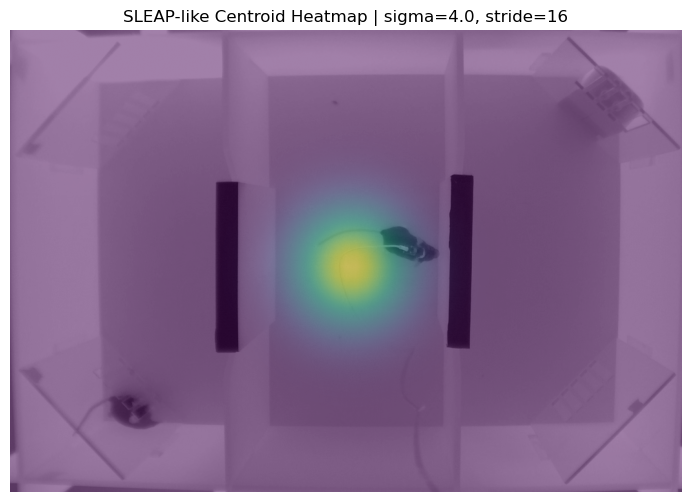

In [8]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt


def make_gaussian_heatmap(height, width, sigma, center=None):
    """
    Erzeugt eine 2D-Gaussian-Heatmap in Heatmap-Auflösung.

    height, width: Größe der Heatmap
    sigma: Sigma in Heatmap-Pixeln
    center: (x, y) in Heatmap-Koordinaten; Standard = Bildmitte
    """
    if center is None:
        center = (width / 2, height / 2)

    x = np.arange(0, width, 1, dtype=np.float32)
    y = np.arange(0, height, 1, dtype=np.float32)
    xx, yy = np.meshgrid(x, y)

    heatmap = np.exp(
        -((xx - center[0]) ** 2 + (yy - center[1]) ** 2) / (2 * sigma ** 2)
    )

    return heatmap



sigma = 4.0         
output_stride = 16   
seed = 1

random.seed(seed)

video_path = r"C:\Users\jrall\Desktop\Bachelorarbeit\Bachelor_Joschua\behavior_videos_maxim\1126 - Gen.Vergleich\trial_2\video0030 25-01-23 19-11-32.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video.")
else:
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    random_frame_idx = random.randint(0, frame_count - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame_idx)
    ret, frame = cap.read()

    if ret:
        sampled_frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_height, frame_width = sampled_frame_gray.shape

        
        heatmap_height = frame_height // output_stride
        heatmap_width = frame_width // output_stride

        
        center_hm = (heatmap_width / 2, heatmap_height / 2)

        
        heatmap = make_gaussian_heatmap(
            height=heatmap_height,
            width=heatmap_width,
            sigma=sigma,
            center=center_hm
        )

        
        heatmap_resized = cv2.resize(
            heatmap,
            (frame_width, frame_height),
            interpolation=cv2.INTER_LINEAR
        )

        
        heatmap_norm = heatmap_resized / heatmap_resized.max()

        
        plt.figure(figsize=(10, 6))
        plt.imshow(sampled_frame_gray, cmap="gray")
        plt.imshow(heatmap_norm, cmap="viridis", alpha=0.5)
        plt.title(
            f"SLEAP-like Centroid Heatmap | sigma={sigma}, stride={output_stride}"
        )
        plt.axis("off")
        plt.show()

    else:
        print("Error: Could not read frame.")

    cap.release()

In [9]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt


def make_gaussian_heatmap(size_x, size_y, sigma, center=None):
    if center is None:
        center = (size_x // 2, size_y // 2)

    x = np.arange(0, size_x, 1)
    y = np.arange(0, size_y, 1)
    xx, yy = np.meshgrid(x, y)

    heatmap = np.exp(-((xx - center[0])**2 + (yy - center[1])**2) / (2 * sigma**2))
    return heatmap



sigma_big = 4.0   
sigma_small = 2.0 
stride = 16



seed = 1
random.seed(seed)

video_path = r'C:\Users\jrall\Desktop\Bachelorarbeit\Bachelor_Joschua\behavior_videos_maxim\1126\trial_2\video0030 25-01-23 19-11-32.mp4'

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video.")
else:
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    random_frame_idx = random.randint(0, frame_count - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame_idx)
    ret, frame = cap.read()

    if ret:
        sampled_frame = frame
        sampled_frame_gray = cv2.cvtColor(sampled_frame, cv2.COLOR_BGR2GRAY)

      
        heatmap_w = width // stride
        heatmap_h = height // stride


        heatmap_big = make_gaussian_heatmap(heatmap_w, heatmap_h, sigma_big)
        heatmap_small = make_gaussian_heatmap(heatmap_w, heatmap_h, sigma_small)

        
        heatmap_big_up = cv2.resize(heatmap_big, (width, height), interpolation=cv2.INTER_LINEAR)
        heatmap_small_up = cv2.resize(heatmap_small, (width, height), interpolation=cv2.INTER_LINEAR)

        
        heatmap_big_up /= heatmap_big_up.max()
        heatmap_small_up /= heatmap_small_up.max()

      
        plt.figure(figsize=(10, 6))
        plt.imshow(sampled_frame_gray, cmap='gray')
        plt.imshow(heatmap_big_up, cmap='jet', alpha=0.5)
        plt.title("Centroid Sigma = 4.0 | Radius ≈ 192 px radius")
        plt.axis('off')
        plt.show()
       
        plt.figure(figsize=(10, 6))
        plt.imshow(sampled_frame_gray, cmap='gray')
        plt.imshow(heatmap_small_up, cmap='jet', alpha=0.5)
        plt.title("Centroid Sigma = 2.0 | Radius ≈ 96 px radius")
        plt.axis('off')
 
        plt.show()

    else:
        print("Error: Could not read frame.")

    cap.release()


Error: Cannot open video.


In [10]:
def overlay_centered_instance(
    frame_gray,
    sigma=2.0,
    crop_size=128,
    output_stride=2,
    anchor_xy=None
):
    h, w = frame_gray.shape

    if anchor_xy is None:
        anchor_xy = (w // 2, h // 2)

    ax, ay = anchor_xy

    
    half = crop_size // 2
    x1 = max(ax - half, 0)
    y1 = max(ay - half, 0)
    x2 = min(ax + half, w)
    y2 = min(ay + half, h)

    crop_w = x2 - x1
    crop_h = y2 - y1

    
    hm_w = crop_w // output_stride
    hm_h = crop_h // output_stride

    
    cx = hm_w // 2
    cy = hm_h // 2

    x = np.arange(hm_w)
    y = np.arange(hm_h)
    xx, yy = np.meshgrid(x, y)

    heatmap = np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sigma**2))

    
    heatmap_up = cv2.resize(heatmap, (crop_w, crop_h), interpolation=cv2.INTER_LINEAR)
    heatmap_up /= heatmap_up.max()

    
    overlay = np.zeros_like(frame_gray, dtype=float)

    
    overlay[y1:y2, x1:x2] = heatmap_up

    return overlay


(np.float64(-0.5), np.float64(1039.5), np.float64(715.5), np.float64(-0.5))

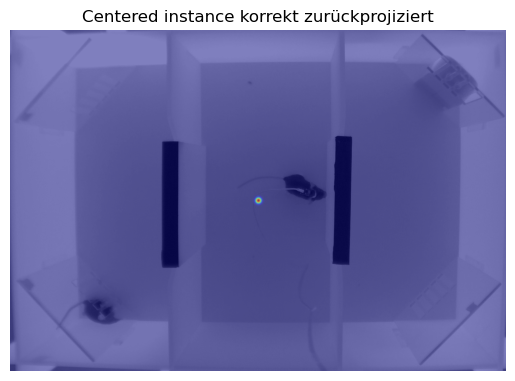

In [11]:
hm_ci = overlay_centered_instance(
    sampled_frame_gray,
    sigma=2.0,
    crop_size=128,
    output_stride=2,
    anchor_xy=(width//2, height//2)  
)

plt.imshow(sampled_frame_gray, cmap="gray")
plt.imshow(hm_ci, cmap="jet", alpha=0.5)
plt.title("Centered instance korrekt zurückprojiziert")
plt.axis("off")


In [12]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

def make_gaussian_heatmap(size_x, size_y, sigma, center=None):
    if center is None:
        center = (size_x // 2, size_y // 2)
    x = np.arange(size_x)
    y = np.arange(size_y)
    xx, yy = np.meshgrid(x, y)
    return np.exp(-((xx - center[0])**2 + (yy - center[1])**2) / (2 * sigma**2))


seed = 1
random.seed(seed)

video_path = r'C:\Users\jrall\Desktop\Bachelorarbeit\Bachelor_Joschua\behavior_videos_maxim\1126\trial_2\video0030 25-01-23 19-11-32.mp4'
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("Cannot open video")

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

idx = random.randint(0, frame_count - 1)
cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not read frame")

frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)


sigma = 2.0
crop_size = 128
output_stride = 2


anchor_xy = (width // 2, height // 2)
ax, ay = anchor_xy


half = crop_size // 2
x1 = max(ax - half, 0)
y1 = max(ay - half, 0)
x2 = min(ax + half, width)
y2 = min(ay + half, height)

crop = frame_gray[y1:y2, x1:x2]
crop_h, crop_w = crop.shape


hm_w = crop_w // output_stride
hm_h = crop_h // output_stride

heatmap = make_gaussian_heatmap(hm_w, hm_h, sigma)


heatmap_up = cv2.resize(heatmap, (crop_w, crop_h), interpolation=cv2.INTER_LINEAR)
heatmap_up = heatmap_up / heatmap_up.max()


plt.figure(figsize=(6, 6))
plt.imshow(crop, cmap="gray")
plt.imshow(heatmap_up, cmap="jet", alpha=0.5, vmin=0, vmax=1)
plt.title(f"Centered instance crop (Frame {idx}) – σ={sigma}, crop={crop_size}")
plt.axis("off")
plt.show()


RuntimeError: Cannot open video

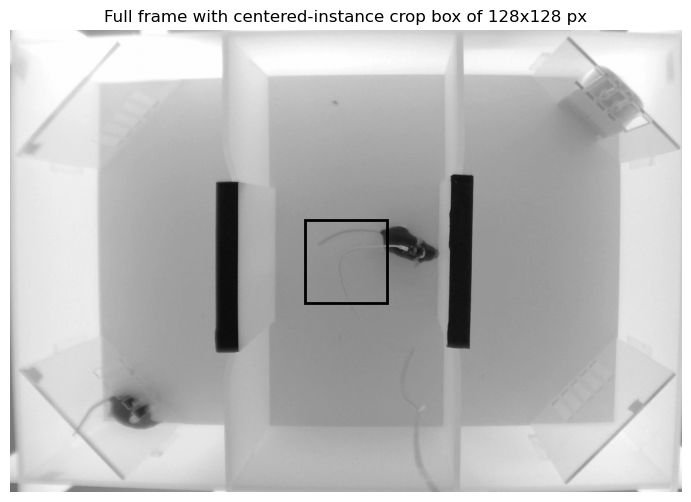

In [ ]:
plt.figure(figsize=(10, 6))
plt.imshow(frame_gray, cmap="gray")
plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2))
plt.title("Full frame with centered-instance crop box of 128x128 px")
plt.axis("off")
plt.show()


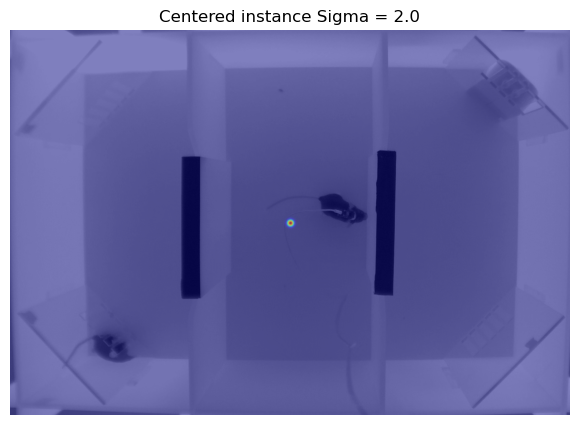

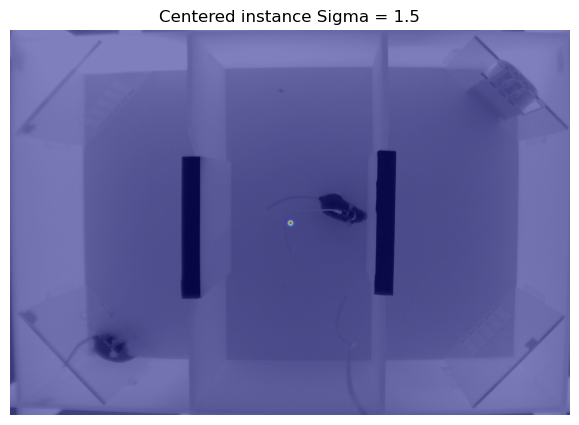

In [ ]:

hm_ci_20 = overlay_centered_instance(
    sampled_frame_gray,
    sigma=2.0,
    crop_size=128,
    output_stride=2,
    anchor_xy=(width//2, height//2)  
)


hm_ci_15 = overlay_centered_instance(
    sampled_frame_gray,
    sigma=1.5,
    crop_size=128,
    output_stride=2,
    anchor_xy=(width//2, height//2) 
)


plt.figure(figsize=(12, 5))


plt.imshow(sampled_frame_gray, cmap="gray")
plt.imshow(hm_ci_20, cmap="jet", alpha=0.5, vmin=0, vmax=1)
plt.title("Centered instance Sigma = 2.0")
plt.axis("off")

plt.show()

plt.figure(figsize=(12, 5))
plt.imshow(frame_gray, cmap="gray")
plt.imshow(hm_ci_15, cmap="jet", alpha=0.5, vmin=0, vmax=1)
plt.title("Centered instance Sigma = 1.5")
plt.axis("off")

plt.show()


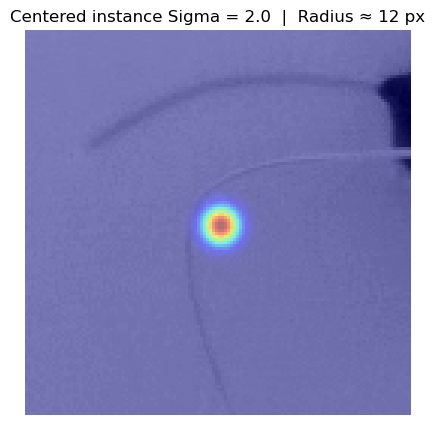

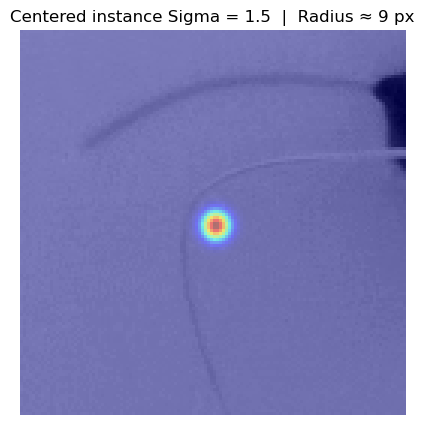

In [ ]:

sigma_big = 2.0
sigma_small = 1.5

heatmap_big = make_gaussian_heatmap(hm_w, hm_h, sigma_big)
heatmap_small = make_gaussian_heatmap(hm_w, hm_h, sigma_small)


heatmap_big_up = cv2.resize(heatmap_big, (crop_w, crop_h), interpolation=cv2.INTER_LINEAR)
heatmap_small_up = cv2.resize(heatmap_small, (crop_w, crop_h), interpolation=cv2.INTER_LINEAR)

heatmap_big_up /= heatmap_big_up.max()
heatmap_small_up /= heatmap_small_up.max()


plt.figure(figsize=(10, 5))


plt.imshow(crop, cmap="gray")
plt.imshow(heatmap_big_up, cmap="jet", alpha=0.5, vmin=0, vmax=1)
plt.title(f"Centered instance Sigma = 2.0  |  Radius ≈ {r_20} px")
plt.axis("off")

plt.figure(figsize=(10, 5))


plt.imshow(crop, cmap="gray")
plt.imshow(heatmap_small_up, cmap="jet", alpha=0.5, vmin=0, vmax=1)
plt.title(f"Centered instance Sigma = 1.5  |  Radius ≈ {r_15} px")
plt.axis("off")

plt.show()


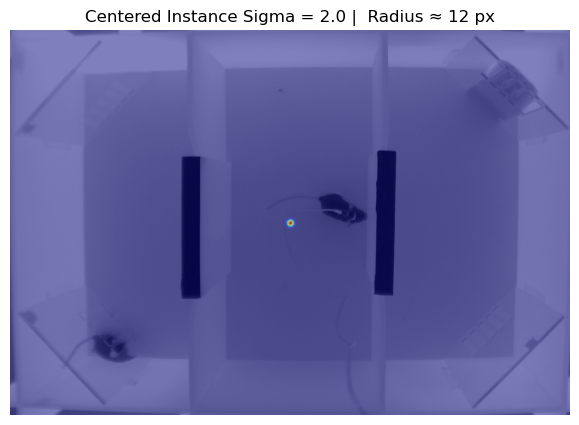

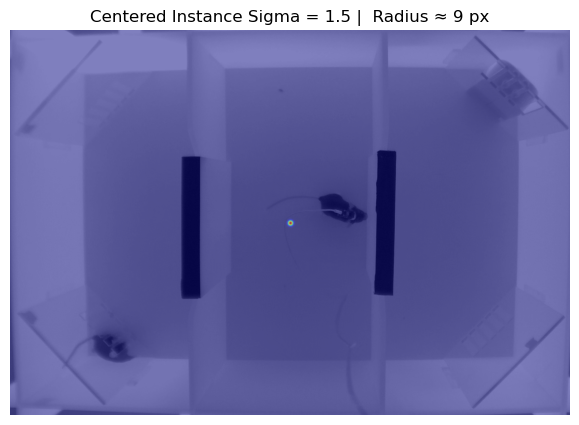

In [ ]:
output_stride = 2

def effective_radius_px(sigma, stride):
    return int(round(3 * sigma * stride))

r_20 = effective_radius_px(2.0, output_stride)
r_15 = effective_radius_px(1.5, output_stride)


hm_ci_20 = overlay_centered_instance(
    sampled_frame_gray,
    sigma=2.0,
    crop_size=128,
    output_stride=output_stride,
    anchor_xy=(width//2, height//2)
)

plt.figure(figsize=(12, 5))
plt.imshow(sampled_frame_gray, cmap="gray")
plt.imshow(hm_ci_20, cmap="jet", alpha=0.5, vmin=0, vmax=1)
plt.title(f"Centered Instance Sigma = 2.0 |  Radius ≈ {r_20} px")
plt.axis("off")
plt.show()


hm_ci_15 = overlay_centered_instance(
    sampled_frame_gray,
    sigma=1.5,
    crop_size=128,
    output_stride=output_stride,
    anchor_xy=(width//2, height//2)
)

plt.figure(figsize=(12, 5))
plt.imshow(sampled_frame_gray, cmap="gray")
plt.imshow(hm_ci_15, cmap="jet", alpha=0.5, vmin=0, vmax=1)
plt.title(f"Centered Instance Sigma = 1.5 |  Radius ≈ {r_15} px")
plt.axis("off")
plt.show()
